# Neural Networks from Scratch: Fitting Non-linear Relationships

In the regression tutorials we fit **straight lines and planes**, and even **polynomials**. But some relationships are so wiggly that *no* polynomial of reasonable degree can describe them — flat plateaus, sharp transitions, a local spike here and there. In this tutorial we build a small **neural network (a multi-layer perceptron, or MLP) from scratch with nothing but NumPy** and use it to fit exactly such a relationship: how a building's **energy consumption** depends on the **outdoor temperature**.

We build the network the way you build with LEGO: start with one **neuron**, snap several together into a **network**, teach it with **backpropagation**, and watch it bend itself to the data. Then we meet the villain of every flexible model — **overfitting** — and defeat it with **validation** and **hyperparameter tuning**, exactly as we did for Ridge/Lasso.

## Learning objectives
- Build a **single sigmoid neuron** and understand it as an adjustable S-shaped curve.
- **Connect neurons into a network** and see how summed sigmoids create arbitrary curves.
- Derive and implement **backpropagation** and fit the model with **gradient descent**.
- See a network fit a shape that **linear regression and polynomials cannot**.
- Watch an **over-complicated model overfit** — great on training data, poor on new data.
- Use a **validation set** to **tune the network size** and recover good generalization.

> This notebook is deliberately written *from scratch* (no PyTorch / TensorFlow) so the mechanics are fully visible. Everything is plain NumPy and a few lines of matplotlib.


### Imports and reproducibility

All imports for this notebook live in the cell below. We need only NumPy for the math and matplotlib for the pictures; polynomial baselines come from NumPy's `polyfit`.

In [2]:
# --- All imports for this notebook live here ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)  # for reproducibility of anything that uses the global RNG

## 0. A genuinely non-linear dataset: energy vs. outdoor temperature

Think about the energy a building uses over a day as a function of the outdoor temperature $T_i$ (in °C). Real HVAC behaviour is full of **flat regions and sharp switches**, not a gentle curve:

- When it is **cold** (below ~5 °C) the heating runs flat-out — a **high plateau**.
- Through the **comfortable** band (~18–24 °C) almost nothing runs — a **low plateau**.
- When it is **hot** (above ~28 °C) the air-conditioning saturates — another **high plateau**.
- Around **15 °C** a scheduled process (say a defrost/ventilation cycle) causes a **local spike**.

We encode this as a sum of two smooth **steps** (sigmoids) plus a **bump** (a Gaussian), with a little measurement noise:

$$\text{energy} \;=\; 7 \;+\; \underbrace{\frac{12}{1+e^{(T_i-7)/2}}}_{\text{heating plateau (cold)}} \;+\; \underbrace{\frac{13}{1+e^{-(T_i-26)/2}}}_{\text{cooling plateau (hot)}} \;+\; \underbrace{6\,e^{-\frac12\left(\frac{T_i-15}{2}\right)^2}}_{\text{local spike}} \;+\; \varepsilon, \qquad \varepsilon\sim\mathcal N(0,\,1.2^2)$$

This is **not** a polynomial — it has flat plateaus and a localized bump, features that polynomials can only mimic by oscillating (the Runge phenomenon). That is the whole point.

In [3]:
def true_f(Ti):
    # The true (noise-free) relationship: two plateaus + a local spike.
    return (7.0
            + 12.0 / (1 + np.exp((Ti - 7) / 2.0))       # cold heating plateau (step down)
            + 13.0 / (1 + np.exp(-(Ti - 26) / 2.0))      # hot cooling plateau (step up)
            + 6.0 * np.exp(-0.5 * ((Ti - 15) / 2.0) ** 2) # local spike ~15 C
            
            # You may also need any noise or other perturbations to the true relationship here, but for now we just return the clean function.
            
            )  

def make_data(n, seed):
    # Sample temperatures and add measurement noise to the true relationship.
    rng = np.random.default_rng(seed)                    # private RNG -> reproducible regardless of run order
    Ti = rng.uniform(-10, 35, n)
    energy = true_f(Ti) + rng.normal(0, 1.2, n)
    return Ti, energy

Ti, energy = make_data(50, seed=0)
print(f"{len(Ti)} samples | Ti in [{Ti.min():.1f}, {Ti.max():.1f}] C | "
      f"energy in [{energy.min():.1f}, {energy.max():.1f}] kWh")

50 samples | Ti in [-9.9, 34.9] C | energy in [7.4, 20.9] kWh


### Let's plot the generated dataset.

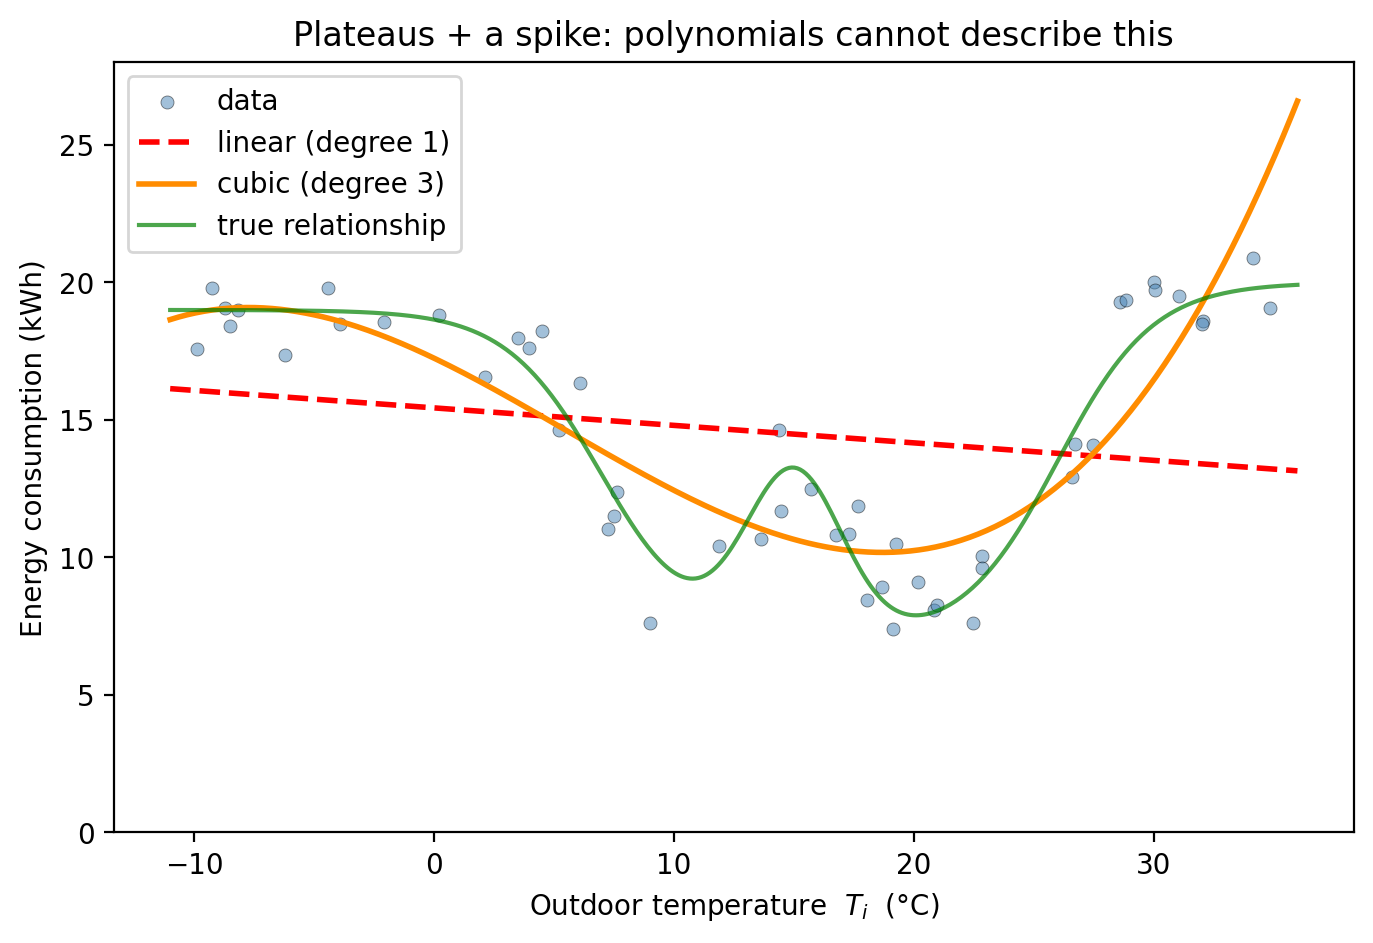

linear (deg 1): MSE = 18.0
cubic  (deg 3): MSE = 4.6


In [56]:
# Fit polynomials of increasing degree -- none of them is any good.
xs = np.linspace(-11, 36, 400)
c1  = np.polyfit(Ti, energy, 1)
c3  = np.polyfit(Ti, energy, 3)

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.scatter(Ti, energy, s=22, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3, label='data')
ax.plot(xs, np.polyval(c1, xs), 'r--', lw=2, label='linear (degree 1)')
ax.plot(xs, np.polyval(c3, xs), color='darkorange', lw=2, label='cubic (degree 3)')
ax.plot(xs, true_f(xs), 'g-', lw=1.5, alpha=0.7, label='true relationship')
ax.set_ylim(0, 28)
ax.set_xlabel('Outdoor temperature  $T_i$  (°C)'); ax.set_ylabel('Energy consumption (kWh)')
ax.set_title('Plateaus + a spike: polynomials cannot describe this')
ax.legend()
plt.show()

for name, c in [('linear (deg 1)', c1), ('cubic  (deg 3)', c3)]:
    print(f"{name}: MSE = {np.mean((np.polyval(c, Ti) - energy)**2):.1f}")

### Understand based on our domain knowledge:

- When the temperature is high, we use air-conditioners --> Higher energy consumption
- When the temperature is low, we use space-heaters --> Higher energy consumption.

**What are we looking at?** The blue cloud has clear **flat shoulders** and a **little hump** near 15 °C. The straight line (red) is hopeless. The cubic (orange) can bend once or twice but cannot be flat, then step, then hump, then flat again. Pushing the degree higher (the degree-10 fit printed above) barely helps and starts to **oscillate near the edges** while chasing noise — classic Runge behaviour. There is simply **no good polynomial** here.

**Takeaway:** We need a model that can form **plateaus, steps, and bumps** on demand. That is exactly what a neural network builds out of sigmoids. Let's construct one.

## 1. One neuron: an adjustable S-curve

The building block of a neural network is a **neuron**. A neuron takes an input $x$, multiplies it by a **weight** $w$, adds a **bias** $b$, and squashes the result through a non-linear **activation function**. We use the **sigmoid**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \text{neuron output} \;=\; \sigma(\,w\,x + b\,).$$

The sigmoid turns any number into a value between 0 and 1 — a smooth **S-curve** (a soft step). The two knobs do intuitive things:
- the **weight $w$** controls how *steep* the step is (and, if negative, flips it),
- the **bias $b$** controls *where along the x-axis* the step sits (it shifts left/right).

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig1.png" alt="01_simple-mlp figure 1" width="640">

Because the sigmoid is smooth, we can compute its **derivative** cleanly — we will need it for training:

$$\sigma'(z) = \sigma(z)\,\bigl(1 - \sigma(z)\bigr).$$

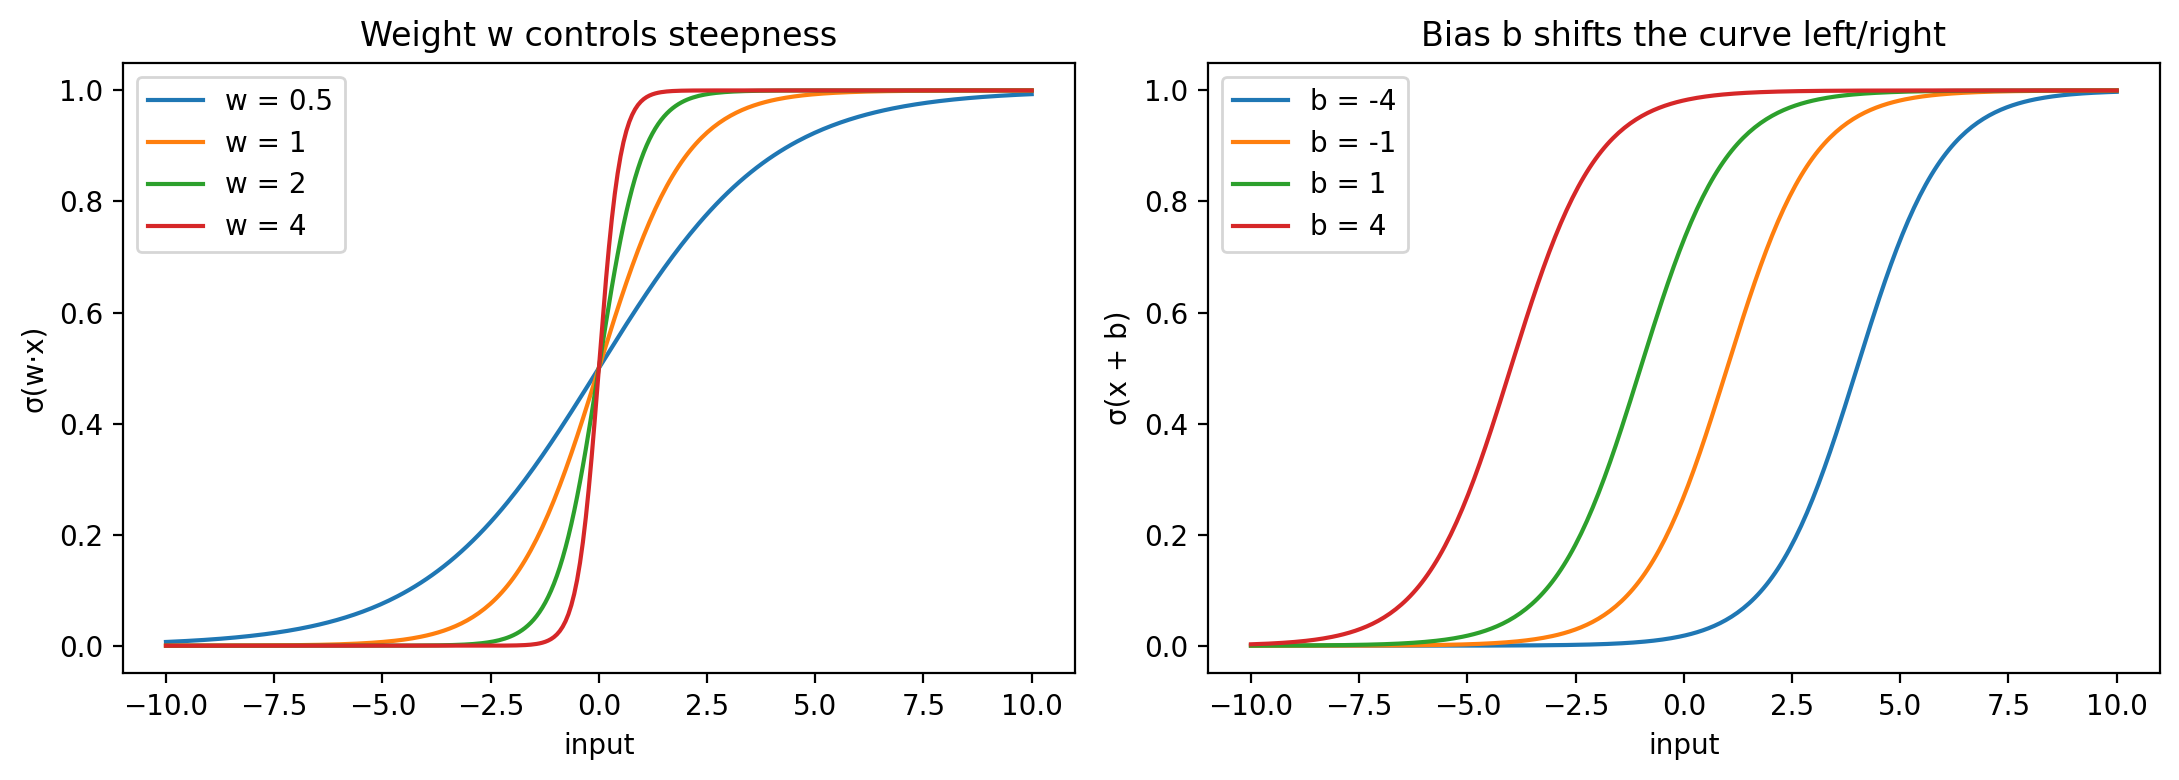

In [19]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

# Show how the weight (steepness) and bias (horizontal shift) reshape one neuron's S-curve.
z = np.linspace(-10, 10, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=200)
for w in [0.5, 1, 2, 4]:
    axes[0].plot(z, sigmoid(w * z), label=f'w = {w}')
axes[0].set_title('Weight w controls steepness'); axes[0].set_xlabel('input'); axes[0].set_ylabel('σ(w·x)')
axes[0].legend()
for b in [-4, -1, 1, 4]:
    axes[1].plot(z, sigmoid(z + b), label=f'b = {b}')
axes[1].set_title('Bias b shifts the curve left/right'); axes[1].set_xlabel('input'); axes[1].set_ylabel('σ(x + b)')
axes[1].legend()
plt.tight_layout(); plt.show()

**Reading the plots:** A single neuron is just a **tunable soft step**. The weight makes the step sharper or softer; the bias slides it to the temperature where it should switch. One neuron alone makes *one* step — not enough for our plateaus-and-bump shape. The trick is to combine many of them.

## 2. Connecting neurons into a network

Put several neurons **side by side** in a **hidden layer**, feed them all the same input $x$, then **add up** their outputs (each with its own weight) in an **output neuron**. For a regression problem the output neuron does *not* squash — it just returns the weighted sum, so the network can output any real number (like kWh).

Our network has three layers: **1 input → $H$ hidden sigmoid neurons → 1 linear output**.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig2.png" alt="01_simple-mlp figure 2" width="640">

In matrix form, with $H$ hidden units, the whole **forward pass** is just two lines of linear algebra with a sigmoid in between:

$$
\mathbf{a}_1 = \sigma\!\big(\underbrace{W_1}_{H\times 1}\,x + \underbrace{\mathbf b_1}_{H\times 1}\big)
\qquad\qquad
\hat y = \underbrace{W_2}_{1\times H}\,\mathbf{a}_1 + b_2 .
$$

**Why does adding sigmoids help?** Each hidden neuron contributes one soft step at its own location and steepness. **Two opposite steps side by side make a bump; several steps make plateaus.** Summing them (with positive and negative output weights) builds any shape we like — including our plateaus-and-spike target. The plot below hand-builds a bump-on-a-step out of just three sigmoids.

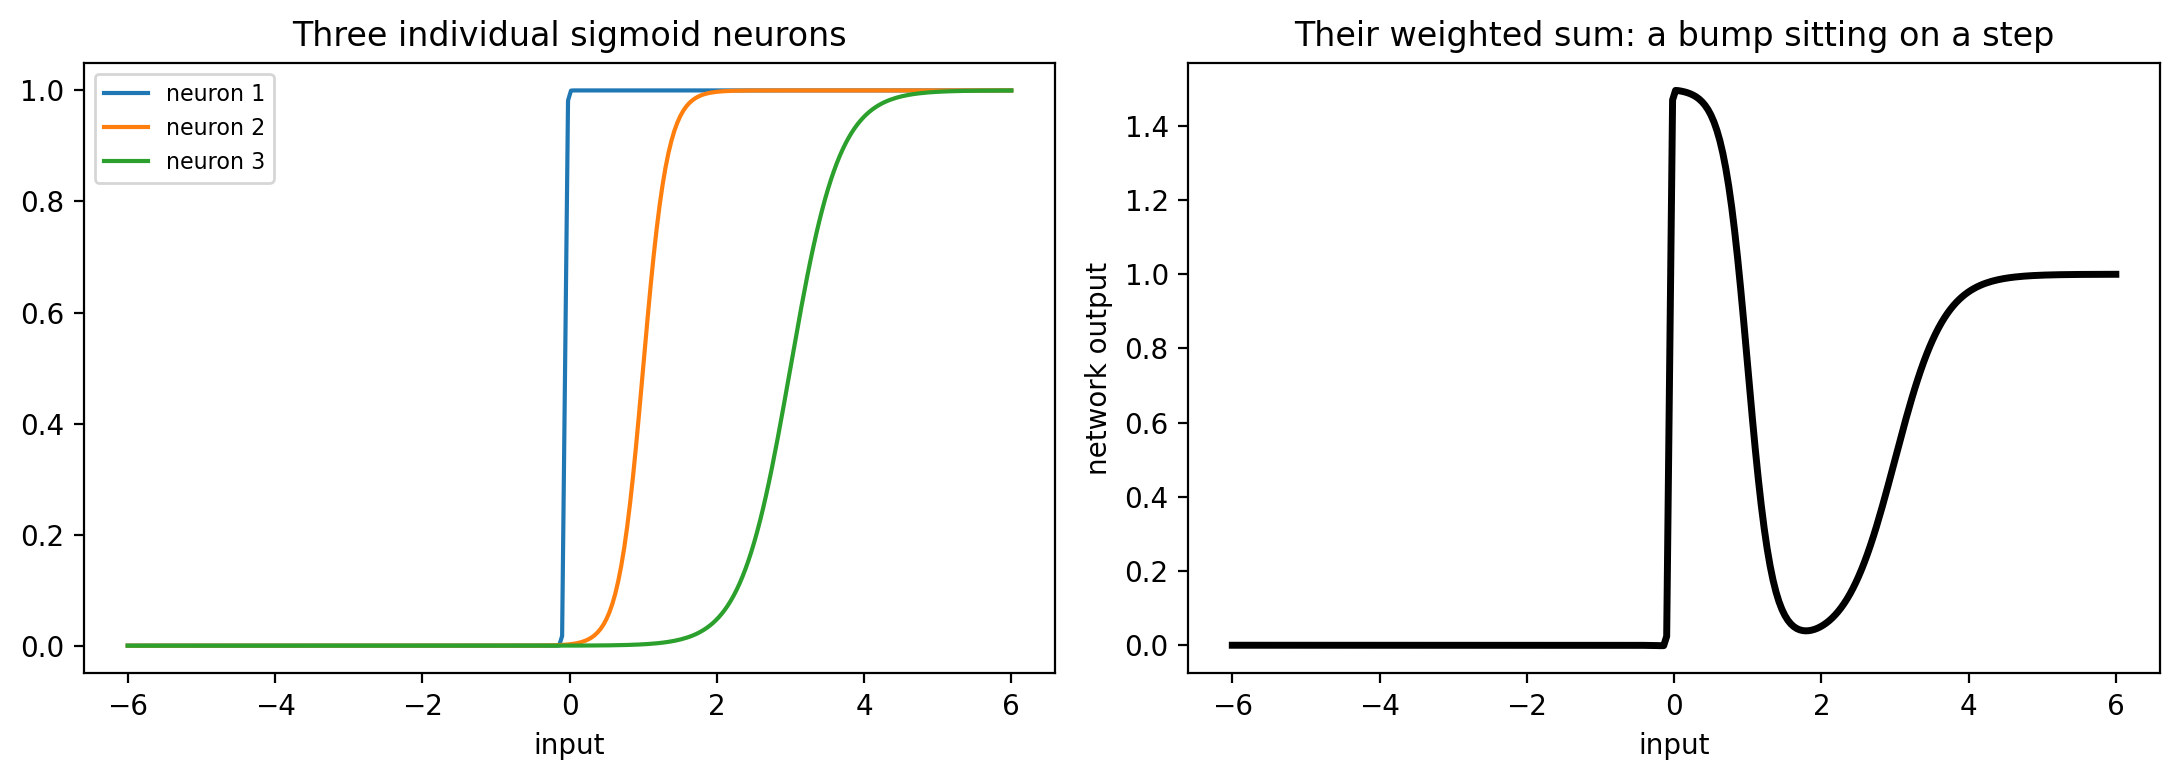

In [46]:
# Hand-pick 3 hidden neurons and sum them: two opposite steps make a bump, a third adds a plateau.
x = np.linspace(-6, 6, 300)
W1 = np.array([ 100.0,  6.0,  3.0])     # steepness of each soft step
b1 = np.array([ 6.0, -6.0, -9.0])     # positions of each step
W2 = np.array([ 1.5, -1.5,  1.0])     # how each neuron adds into the output

# a1 = sigmoid (Wx + b) for each neuron, then sum them up with W2
hidden = sigmoid(W1[:, None] * x[None, :] + b1[:, None])   # (3, 300)

# y = W2 * hidden for each neuron, then sum them up with W2
output = W2 @ hidden                                        # (300,)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=200)
for i in range(3):
    axes[0].plot(x, hidden[i], lw=1.5, label=f'neuron {i+1}')
axes[0].set_title('Three individual sigmoid neurons'); axes[0].set_xlabel('input'); axes[0].legend(fontsize=8)
axes[1].plot(x, output, color='black', lw=2.5)
axes[1].set_title('Their weighted sum: a bump sitting on a step'); axes[1].set_xlabel('input'); axes[1].set_ylabel('network output')
plt.tight_layout(); plt.show()

**Takeaway:** Individually the three neurons are boring soft steps (left). **Added together they form a bump on a plateau** (right) — the very kind of feature our dataset has, and one no straight line or low-degree polynomial can make. A real network *learns* the weights and biases that shape the curve, instead of us picking them by hand. That learning is the next section.

## 3. Training: backpropagation + gradient descent

Learning means finding the weights $\{W_1, \mathbf b_1, W_2, b_2\}$ that make the predictions $\hat y$ close to the true $y$. "Close" is measured by the **mean squared error (MSE)** loss:

$$L = \frac{1}{N}\sum_{n=1}^{N} \tfrac12\,(\hat y_n - y_n)^2 .$$

**Gradient descent** repeatedly nudges every parameter a small step *downhill* on this loss: $\;\theta \leftarrow \theta - \eta\,\dfrac{\partial L}{\partial \theta}$, where $\eta$ is the **learning rate**. The only hard part is computing the gradients $\partial L/\partial \theta$ — and **backpropagation** does it efficiently by applying the chain rule from the output backwards to the input.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig3.png" alt="01_simple-mlp figure 3" width="700">

Applying the chain rule to our 1-hidden-layer network gives compact, vectorised gradients (here $X$ is $1\times N$, $Y$ is $1\times N$):

1. **Output error:** $\;\mathrm dZ_2 = \dfrac{1}{N}(\hat Y - Y)$
2. **Output weights:** $\;\mathrm dW_2 = \mathrm dZ_2\,A_1^{\top}, \qquad \mathrm db_2 = \textstyle\sum \mathrm dZ_2$
3. **Backprop into the hidden layer:** $\;\mathrm dZ_1 = (W_2^{\top}\,\mathrm dZ_2)\,\odot\,\sigma'(Z_1)$
4. **Hidden weights:** $\;\mathrm dW_1 = \mathrm dZ_1\,X^{\top}, \qquad \mathrm db_1 = \textstyle\sum \mathrm dZ_1$

The $\sigma'(Z_1)$ factor in step 3 is exactly why we needed the sigmoid's derivative. Below, all of this is about 15 lines of NumPy.

**One practical step first — scaling.** Sigmoids saturate for large inputs (their gradient goes to zero), so we **standardise** $T_i$ and energy to mean 0 / std 1 before training, and undo the scaling when we plot. We fit the scaler on the data we train on.

### 3.1 Backpropagation is just the chain rule

Section 3 listed four gradient formulas — here is where they come from. For a single training example the loss flows through a short chain of operations,

$$x \;\xrightarrow{\,W_1,\ \mathbf b_1\,}\; z_1 \;\xrightarrow{\ \sigma\ }\; a_1 \;\xrightarrow{\,W_2,\ b_2\,}\; \hat y \;\longrightarrow\; L=\tfrac12(\hat y-y)^2,$$

and a change in an early weight can only reach $L$ by passing through every later stage. The **chain rule** says the total derivative is then the *product* of the local derivative at each stage:

$$\frac{\partial L}{\partial W_1} \;=\; \underbrace{\frac{\partial L}{\partial \hat y}}_{\hat y - y}\;\cdot\;\underbrace{\frac{\partial \hat y}{\partial a_1}}_{W_2}\;\cdot\;\underbrace{\frac{\partial a_1}{\partial z_1}}_{\sigma'(z_1)}\;\cdot\;\underbrace{\frac{\partial z_1}{\partial W_1}}_{x}.$$

Evaluating that product **right-to-left** — from the output error back toward the input — is exactly what "**back**propagation" means.

**Each local factor is elementary:**

- Loss vs. output: $\dfrac{\partial L}{\partial \hat y} = \hat y - y$, the raw prediction error.
- Linear output layer $\hat y = W_2 a_1 + b_2$: $\dfrac{\partial \hat y}{\partial a_1}=W_2$, and directly $\dfrac{\partial \hat y}{\partial W_2}=a_1,\ \dfrac{\partial \hat y}{\partial b_2}=1$.
- Sigmoid: $\dfrac{\partial a_1}{\partial z_1}=\sigma'(z_1)$ — the derivative we built in Section 1.
- Affine hidden layer $z_1 = W_1 x + \mathbf b_1$: $\dfrac{\partial z_1}{\partial W_1}=x,\ \dfrac{\partial z_1}{\partial \mathbf b_1}=1$.

**Why "backprop" and not just "the chain rule"?** Define an **error signal** at each layer — the loss's sensitivity to that layer's pre-activation:

$$\delta_2 \;=\; \frac{\partial L}{\partial \hat y} \;=\; \hat y - y, \qquad \delta_1 \;=\; \frac{\partial L}{\partial z_1} \;=\; \big(W_2^{\top}\delta_2\big)\odot\sigma'(z_1).$$

The point is that $\delta_1$ **reuses** $\delta_2$ instead of re-deriving the whole path from scratch. So *every* gradient costs a single backward sweep, not one separate chain per weight — that reuse is the entire efficiency win. The four vectorised updates from Section 3 (with $X$ of shape $1\times N$, and the $\tfrac1N$ averaging the loss over the batch) then read straight off the chain:

$$\mathrm dZ_2=\tfrac1N(\hat Y-Y),\quad \mathrm dW_2=\mathrm dZ_2\,A_1^{\top},\quad \mathrm dZ_1=\big(W_2^{\top}\mathrm dZ_2\big)\odot\sigma'(Z_1),\quad \mathrm dW_1=\mathrm dZ_1\,X^{\top},$$

with $\mathrm db_2=\sum \mathrm dZ_2$ and $\mathrm db_1=\sum \mathrm dZ_1$. Every symbol is one of the local derivatives above, multiplied in chain-rule order.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig4.png" alt="01_simple-mlp figure 4" width="760">

**Reading the diagram:** each gradient is a chain of local derivatives multiplied together, one factor per operation the signal passed through. Deeper weights ($W_1$) sit at the end of a longer chain than shallow ones ($W_2$); the shared output-error factor $\delta_2=\hat y-y$ (red) is computed once and reused — so the whole backward pass is linear in the number of parameters.

In [21]:
class Scaler:
    # Standardise to mean 0, std 1 (and invert). Fit on training data only.
    def __init__(self, v): self.m, self.s = v.mean(), v.std()
    def z(self, v):   return (v - self.m) / self.s
    def unz(self, v): return v * self.s + self.m

def init_net(H, seed):
    # A 1 -> H -> 1 network. Random weights break symmetry; biases spread the S-curves out.
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0, 1, (H, 1)),
        "b1": rng.normal(0, 2, (H, 1)),
        "W2": rng.normal(0, 1, (1, H)) / np.sqrt(H),
        "b2": np.zeros((1, 1)),
    }

def forward(net, X):
    Z1 = net["W1"] @ X + net["b1"]     # (H, N)
    A1 = sigmoid(Z1)                    # (H, N)
    Z2 = net["W2"] @ A1 + net["b2"]    # (1, N)  -- linear output, no squashing
    return Z2, (Z1, A1)

def train(net, X, Y, lr, epochs, record=False):
    N = X.shape[1]
    losses = []
    for e in range(epochs):
        # ---- forward ----
        Yhat, (Z1, A1) = forward(net, X)
        if record and e % 100 == 0:
            losses.append(np.mean(0.5 * (Yhat - Y) ** 2))
        # ---- backward (the 4 steps above) ----
        dZ2 = (Yhat - Y) / N
        dW2 = dZ2 @ A1.T
        db2 = dZ2.sum(axis=1, keepdims=True)
        dZ1 = (net["W2"].T @ dZ2) * sigmoid_prime(Z1)
        dW1 = dZ1 @ X.T
        db1 = dZ1.sum(axis=1, keepdims=True)
        # ---- gradient-descent update ----
        net["W1"] -= lr * dW1; net["b1"] -= lr * db1
        net["W2"] -= lr * dW2; net["b2"] -= lr * db2
    return net, losses

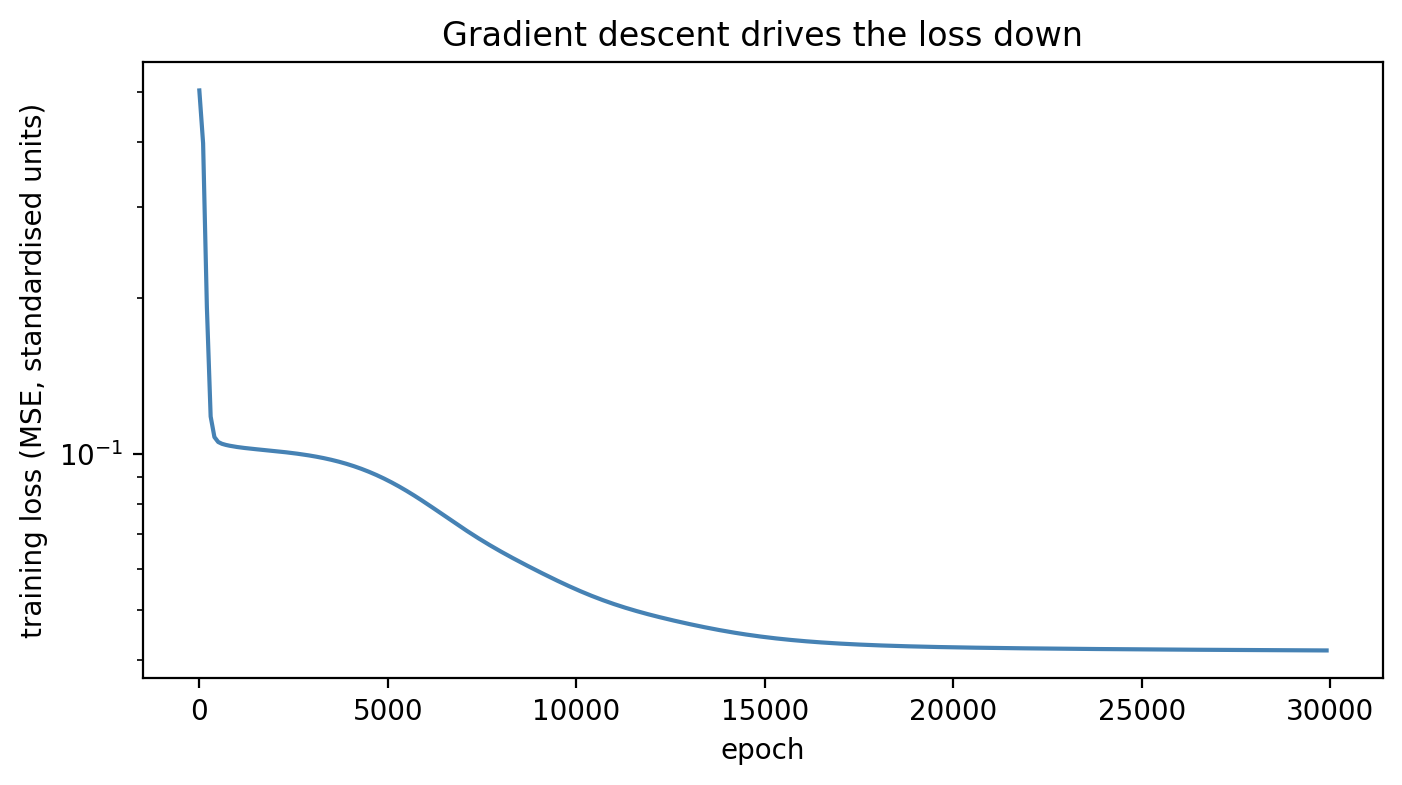

loss: 0.503  ->  0.042


In [22]:
# Standardise, then train a network with H = 12 hidden neurons on the full dataset.
sx, sy = Scaler(Ti), Scaler(energy)
X = sx.z(Ti).reshape(1, -1)
Y = sy.z(energy).reshape(1, -1)

net, losses = train(init_net(H=12, seed=10), X, Y, lr=0.3, epochs=30000, record=True)

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
ax.plot(np.arange(len(losses)) * 100, losses, color='steelblue')
ax.set_xlabel('epoch'); ax.set_ylabel('training loss (MSE, standardised units)')
ax.set_title('Gradient descent drives the loss down')
ax.set_yscale('log')
plt.show()
print(f"loss: {losses[0]:.3f}  ->  {losses[-1]:.3f}")

**Reading the loss curve:** Every epoch, backprop tells each weight which way is downhill and gradient descent takes a small step. The loss falls by more than an order of magnitude and then flattens — the network has settled into a good fit. Let's see what that fit looks like.

## 4. How the model fits the data

We now run the trained network across the whole temperature range and plot its prediction on top of the data (converting back to real kWh units). We compare it against the best **degree-10 polynomial** from Section 0 — the most flexible polynomial we tried.

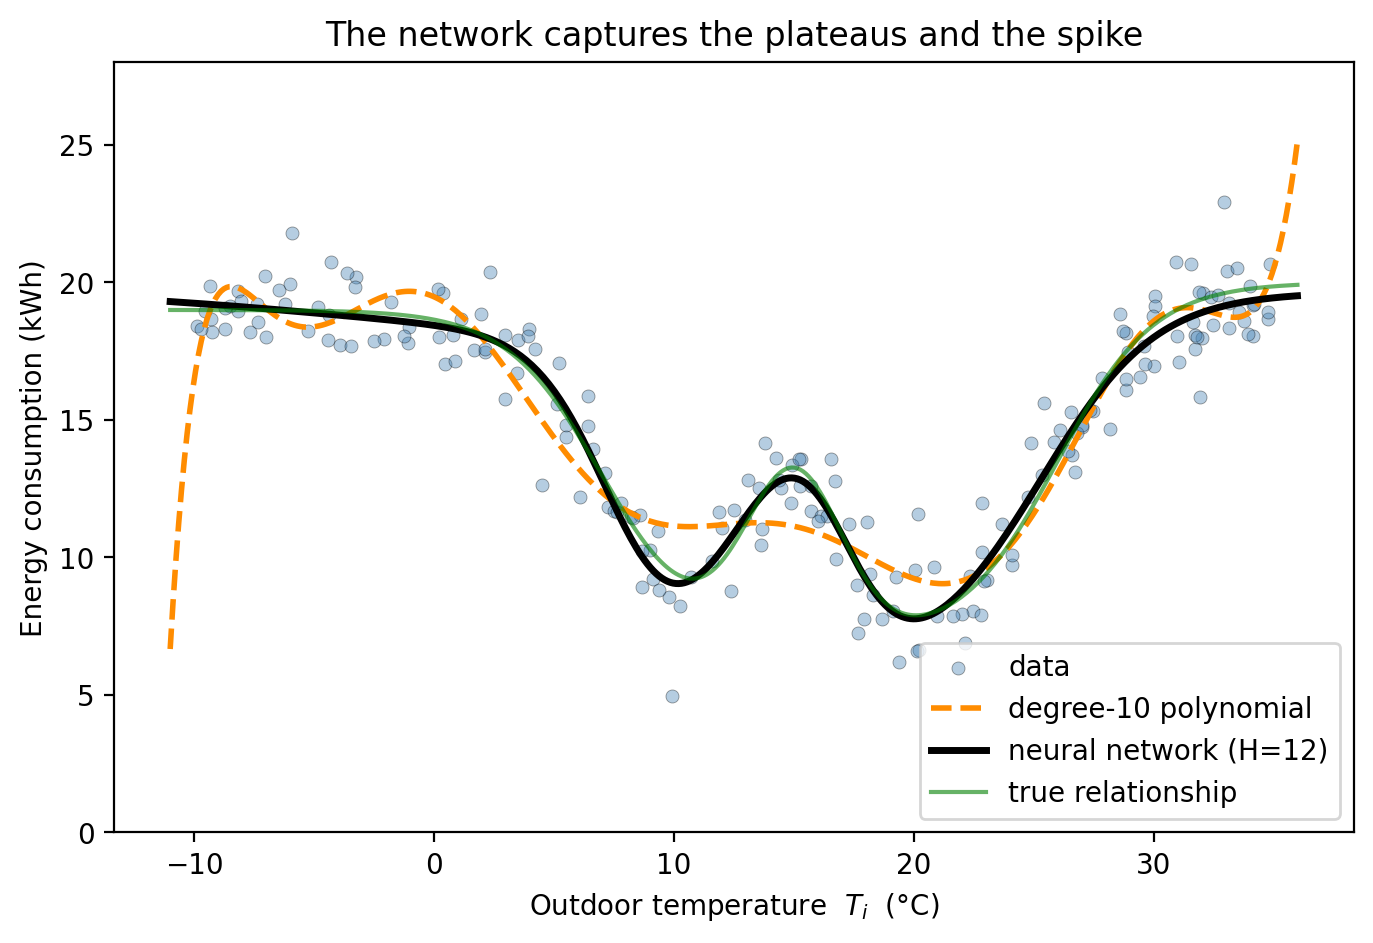

MSE  ->  neural network: 1.44    degree-10 polynomial: 2.29


In [23]:
grid = np.linspace(-11, 36, 400)
mlp_pred = sy.unz(forward(net, sx.z(grid).reshape(1, -1))[0].ravel())

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.scatter(Ti, energy, s=22, alpha=0.4, color='steelblue', edgecolor='black', linewidth=0.3, label='data')
ax.plot(grid, np.polyval(c10, grid), color='darkorange', lw=2, ls='--', label='degree-10 polynomial')
ax.plot(grid, mlp_pred, color='black', lw=2.5, label='neural network (H=12)')
ax.plot(grid, true_f(grid), 'g-', lw=1.5, alpha=0.6, label='true relationship')
ax.set_ylim(0, 28)
ax.set_xlabel('Outdoor temperature  $T_i$  (°C)'); ax.set_ylabel('Energy consumption (kWh)')
ax.set_title('The network captures the plateaus and the spike')
ax.legend()
plt.show()

mlp_mse  = np.mean((sy.unz(forward(net, X)[0].ravel()) - energy) ** 2)
poly_mse = np.mean((np.polyval(c10, Ti) - energy) ** 2)
print(f"MSE  ->  neural network: {mlp_mse:.2f}    degree-10 polynomial: {poly_mse:.2f}")

**Takeaway:** The same tool — a dozen sigmoid neurons and gradient descent — discovered the plateaus, the sharp switches, and the little spike on its own, reaching an MSE right at the **noise floor** and beating even the flexible degree-10 polynomial (which sags at the plateaus and wiggles near the edges). **We never told it the shape; it learned it from the data.** That flexibility is the strength of neural networks. It is also their weakness, as we see next.

## 5. When a model is too complicated: overfitting

More hidden neurons = more knobs = more flexibility. Surely more is always better? **No.** A model with far more capacity than the data warrants will start **memorising the noise** instead of learning the trend. It threads itself through every training point — including the random wobble — and then predicts nonsense between them.

This is the same **bias–variance trade-off** you saw with high-degree polynomials and with un-regularised Ridge/Lasso:

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig5.png" alt="01_simple-mlp figure 5" width="660">

To see it, we train on a **small** dataset (only 20 noisy points) and compare a **modest** network (H=8) against an **over-sized** one (H=60) trained for a long time. We judge both on a large, unseen **test set**.

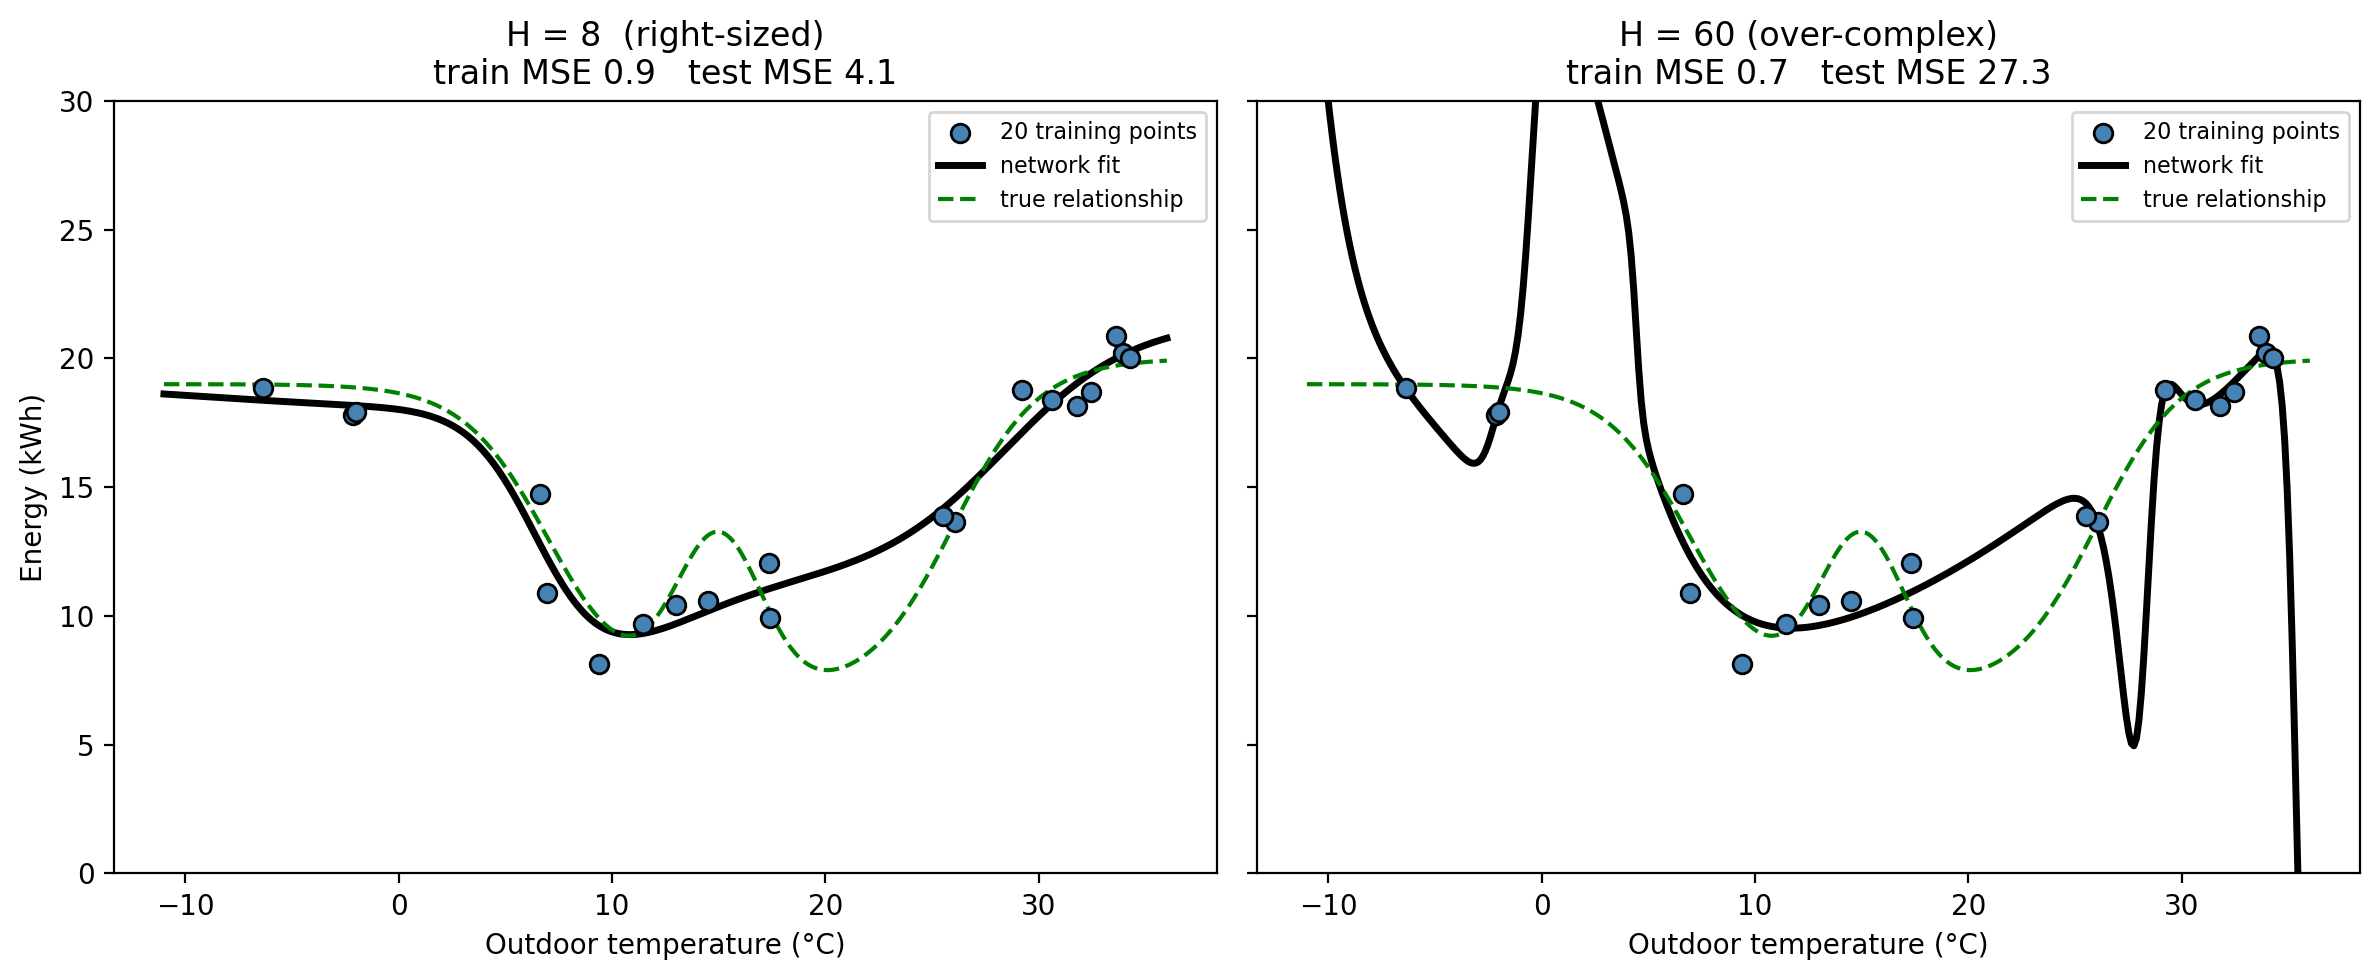

H=8    train MSE   0.9   test MSE   4.1
H=60   train MSE   0.7   test MSE  27.3


In [24]:
# small noisy training set + large clean test set
Ti_tr, en_tr = make_data(20, seed=4)
Ti_te, en_te = make_data(600, seed=104)

sxt, syt = Scaler(Ti_tr), Scaler(en_tr)          # fit the scaler on TRAINING data only
Xtr = sxt.z(Ti_tr).reshape(1, -1); Ytr = syt.z(en_tr).reshape(1, -1)

def test_mse(net):    # MSE on the held-out test set, in real kWh units
    pred = syt.unz(forward(net, sxt.z(Ti_te).reshape(1, -1))[0].ravel())
    return np.mean((pred - en_te) ** 2)
def train_mse(net):
    pred = syt.unz(forward(net, Xtr)[0].ravel())
    return np.mean((pred - en_tr) ** 2)

small, _ = train(init_net(H=8,  seed=11), Xtr, Ytr, lr=0.3, epochs=20000)
big,   _ = train(init_net(H=60, seed=11), Xtr, Ytr, lr=0.3, epochs=40000)

grid = np.linspace(-11, 36, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=200, sharey=True)
for ax, net_, name in [(axes[0], small, 'H = 8  (right-sized)'),
                       (axes[1], big,   'H = 60 (over-complex)')]:
    ax.scatter(Ti_tr, en_tr, s=45, color='steelblue', edgecolor='black', zorder=3, label='20 training points')
    pred = syt.unz(forward(net_, sxt.z(grid).reshape(1, -1))[0].ravel())
    ax.plot(grid, pred, color='black', lw=2.5, label='network fit')
    ax.plot(grid, true_f(grid), 'g--', lw=1.5, label='true relationship')
    ax.set_title(f'{name}\ntrain MSE {train_mse(net_):.1f}   test MSE {test_mse(net_):.1f}')
    ax.set_xlabel('Outdoor temperature (°C)'); ax.set_ylim(0, 30); ax.legend(fontsize=8)
axes[0].set_ylabel('Energy (kWh)')
plt.tight_layout(); plt.show()

print(f"H=8    train MSE {train_mse(small):5.1f}   test MSE {test_mse(small):5.1f}")
print(f"H=60   train MSE {train_mse(big):5.1f}   test MSE {test_mse(big):5.1f}")

**What went wrong?** The over-sized network (right) has the **lower training error** — it bends to pass closer to the 20 points — but a **much higher test error**, because between the points it swings wildly away from the true green curve. The modest network (left) cannot chase the noise, so it stays smooth and **generalises far better to unseen temperatures**.

**Takeaway:** *Training error is a liar.* A model that fits the training data best is not the model that predicts new data best. Lower training loss bought by extra capacity can *increase* the error that actually matters. We need an honest way to choose the network size — that is validation.

## 6. Validation and hyperparameter tuning

The number of hidden neurons $H$ is a **hyperparameter**: we set it *before* training, and gradient descent never adjusts it. We cannot choose it by training error (Section 5 showed that always favours the bigger network). Instead we hold out a **validation set** the model never trains on, and pick the $H$ that does best there — exactly the role cross-validation played when choosing Ridge's `alpha`.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig6.png" alt="01_simple-mlp figure 6" width="620">

We sweep $H$ over a range, train each network on the **training** split, and measure error on the **validation** split. The winner is the $H$ with the lowest validation error — then, and only then, we look at the **test** set to report an honest final number.

Best hidden size by validation: H = 8


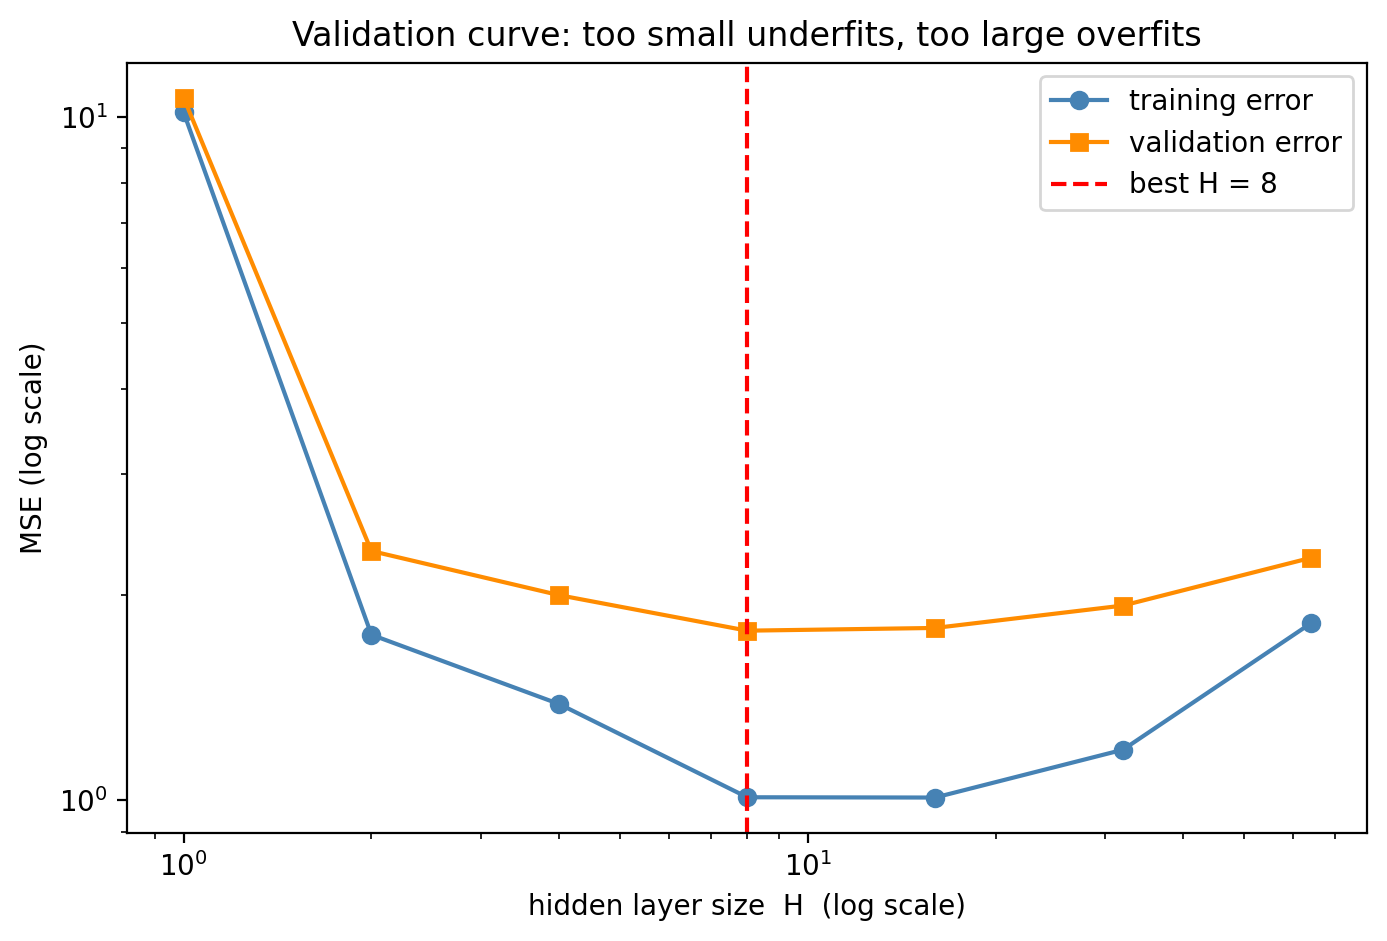

In [ ]:
Ti_tr, en_tr = make_data(80,  seed=1)    # train
Ti_va, en_va = make_data(120, seed=2)    # validation (choose H)
Ti_te, en_te = make_data(600, seed=3)    # test (final report only)

sc_x, sc_y = Scaler(Ti_tr), Scaler(en_tr)
Xtr = sc_x.z(Ti_tr).reshape(1, -1); Ytr = sc_y.z(en_tr).reshape(1, -1)

def mse_on(net, Tval, yval):
    pred = sc_y.unz(forward(net, sc_x.z(Tval).reshape(1, -1))[0].ravel())
    return np.mean((pred - yval) ** 2)

H_grid = [1, 2, 4, 8, 16, 32, 64]
train_scores, val_scores, nets = [], [], {}
for H in H_grid:
    net_, _ = train(init_net(H, seed=12), Xtr, Ytr, lr=0.3, epochs=40000)
    nets[H] = net_
    train_scores.append(mse_on(net_, Ti_tr, en_tr))
    val_scores.append(mse_on(net_, Ti_va, en_va))

best_H = H_grid[int(np.argmin(val_scores))]
print(f"Best hidden size by validation: H = {best_H}")

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.plot(H_grid, train_scores, 'o-', color='steelblue', label='training error')
ax.plot(H_grid, val_scores, 's-', color='darkorange', label='validation error')
ax.axvline(best_H, color='red', linestyle='--', label=f'best H = {best_H}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('hidden layer size  H  (log scale)'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Validation curve: too small underfits, too large overfits')
ax.legend()
plt.show()

**Reading the validation curve:** On the **left** (tiny $H$) both errors are high — the network is too simple to form the plateaus and spike (**underfitting**). As $H$ grows, both errors drop into a **sweet spot**. Past it, training error keeps inching down while **validation error climbs** — the network is spending its extra capacity on noise (**overfitting**). The dashed red line marks the $H$ our validation set prefers.

Chosen model H=8:  validation MSE 1.77   test MSE 1.69


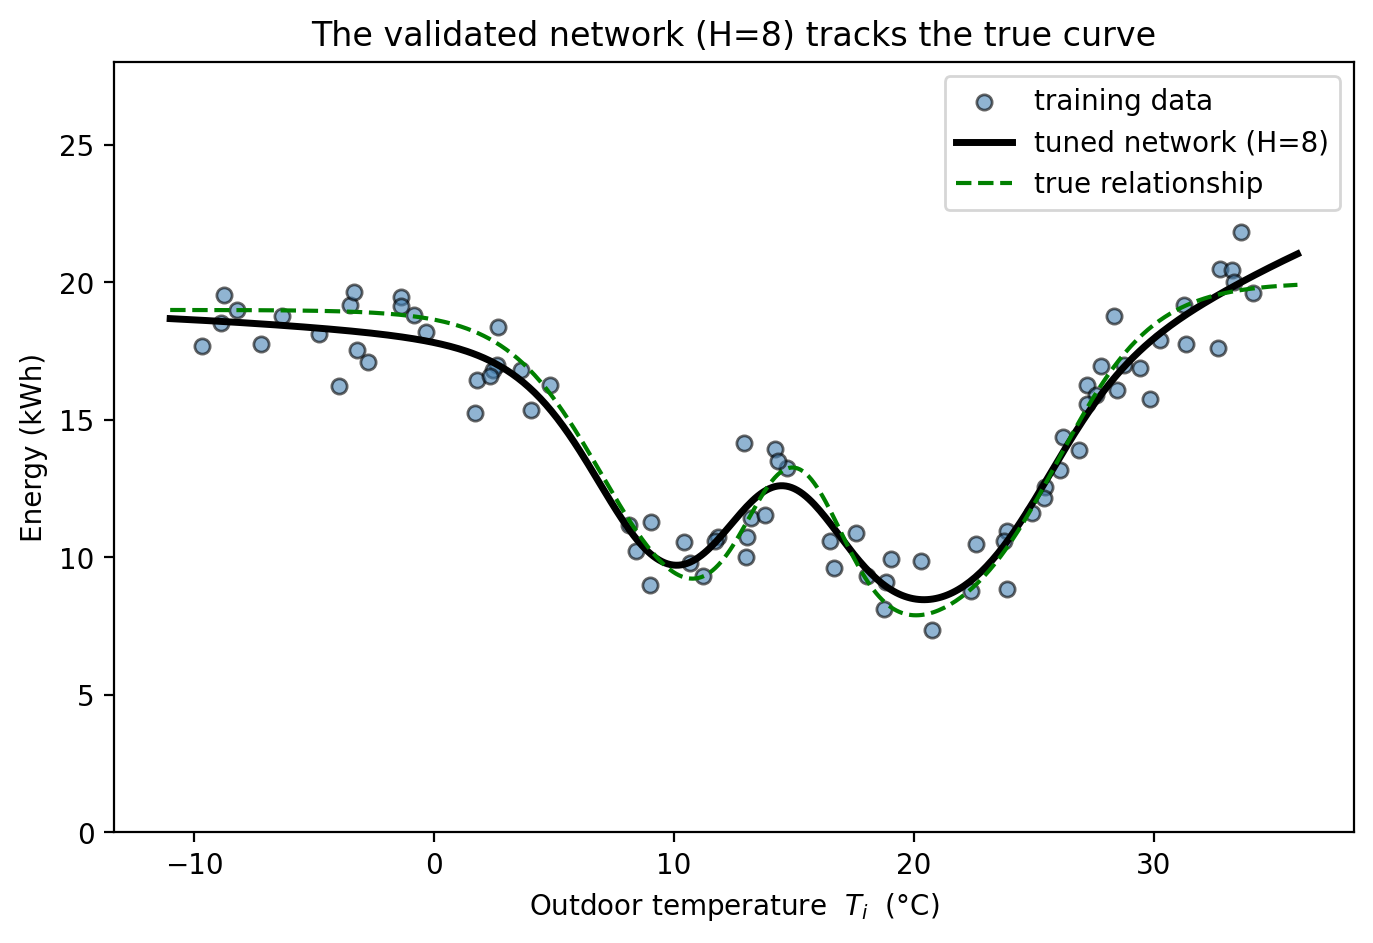

In [26]:
# Report the chosen model on the untouched TEST set, and draw its fit.
best_net = nets[best_H]
print(f"Chosen model H={best_H}:  validation MSE {mse_on(best_net, Ti_va, en_va):.2f}   "
      f"test MSE {mse_on(best_net, Ti_te, en_te):.2f}")

grid = np.linspace(-11, 36, 400)
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.scatter(Ti_tr, en_tr, s=30, alpha=0.6, color='steelblue', edgecolor='black', label='training data')
ax.plot(grid, sc_y.unz(forward(best_net, sc_x.z(grid).reshape(1, -1))[0].ravel()),
        color='black', lw=2.5, label=f'tuned network (H={best_H})')
ax.plot(grid, true_f(grid), 'g--', lw=1.5, label='true relationship')
ax.set_ylim(0, 28)
ax.set_xlabel('Outdoor temperature  $T_i$  (°C)'); ax.set_ylabel('Energy (kWh)')
ax.set_title(f'The validated network (H={best_H}) tracks the true curve')
ax.legend()
plt.show()

**Takeaway:** By letting a **validation set** choose the hyperparameter, we picked a network that is flexible enough to capture the plateaus and spike but not so flexible that it chases noise — and we confirmed it on a **test set the model never saw**. This is the same discipline as tuning `alpha` in regularisation: *never let the training error pick your model's complexity.*

## 7. From regression to classification

Everything so far predicted **one number** (energy). The companion notebook `neural-network-demo.ipynb` uses the **same machinery** for a different job — recognising handwritten digits. Remarkably little changes. The neuron, the sigmoid, the forward pass, and backpropagation are all exactly what we built above; we only change **what comes out of the last layer and how we score it**.

Three differences, and nothing else:

| | Regression (Sections 0–6) | Classification (this section) |
|---|---|---|
| **Output layer** | 1 neuron, a real number | **10 neurons**, one score per digit |
| **Target** | the true value $y$ | a **one-hot** vector, e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]` |
| **Prediction** | the output itself | the **most active** output (`argmax`) |
| **Training** | full-batch gradient descent | **mini-batch** stochastic gradient descent |

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig7.png" alt="01_simple-mlp figure 7" width="620">

### 7.1 The data: 8×8 handwritten digits

We use scikit-learn's built-in `digits` dataset — 1,797 images of handwritten digits, each just **8×8 = 64 pixels** (a compact stand-in for the 28×28 MNIST in the companion notebook, with no download needed). Flattened, each image is a 64-number input vector; we scale pixels from 0–16 down to 0–1, the same "keep the inputs small" habit from Section 3.

train 1257 images, test 540 images, 64 pixels each


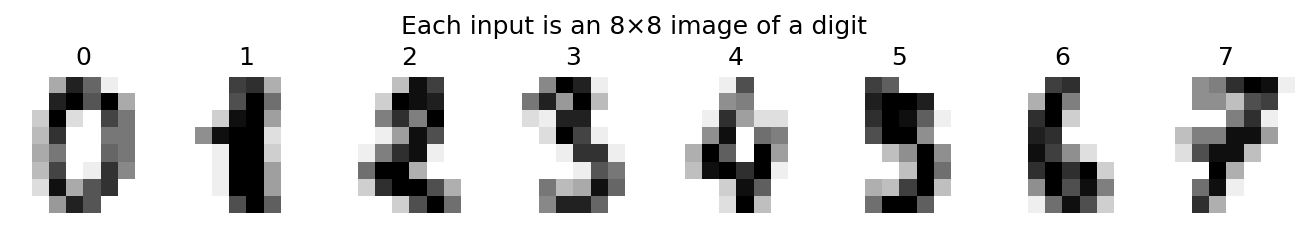

In [27]:
digits = load_digits()
Xall = digits.data / 16.0          # 1797 x 64, pixels 0..16 -> 0..1
yall = digits.target               # labels 0..9
Xtr, Xte, ytr, yte = train_test_split(Xall, yall, test_size=0.3, random_state=0)
print(f"train {Xtr.shape[0]} images, test {Xte.shape[0]} images, {Xtr.shape[1]} pixels each")

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8), dpi=150)
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap='gray_r'); ax.set_title(str(lab)); ax.axis('off')
plt.suptitle('Each input is an 8×8 image of a digit'); plt.show()

### 7.2 One-hot targets and reading the output

The network ends in **10 sigmoid neurons**, one per digit. Each outputs a score between 0 and 1 — think of it as "how much do I look like a 4?". To train it we need a target for each of those 10 outputs, so we turn each label into a **one-hot vector**: all zeros except a single 1 at the correct digit.

$$\text{label } 3 \;\longrightarrow\; \mathbf y = [\,0,0,0,\mathbf 1,0,0,0,0,0,0\,]^\top$$

The network learns to push the right output towards 1 and the rest towards 0. At prediction time we simply take the **`argmax`** — the index of the most active output. (Modern classifiers usually pair a *softmax* output with *cross-entropy* loss; we keep sigmoid outputs with the squared-error loss so the **exact backprop from Section 3 carries over unchanged** — the derivative $\,\hat y - y\,$ is identical.)

In [28]:
# one-hot encode the training labels into a (10 x N) matrix: column n is 1 at row ytr[n]
Ytr = np.zeros((10, len(ytr)))
Ytr[ytr, np.arange(len(ytr))] = 1.0
Xtr_, Xte_ = Xtr.T, Xte.T          # the network expects data shaped (features, N)

print("first three training labels:", ytr[:3])
print("as one-hot columns:\n", Ytr[:, :3].astype(int))

first three training labels: [9 3 6]
as one-hot columns:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 1 0]
 [0 0 0]
 [0 0 0]
 [0 0 1]
 [0 0 0]
 [0 0 0]
 [1 0 0]]


### 7.3 Mini-batch stochastic gradient descent

In Sections 3–6 we computed the gradient over the **whole** training set before each step (*full-batch* gradient descent). With thousands of images that is slow, and a smooth exact gradient can crawl into a poor spot and stall. **Mini-batch SGD** fixes both:

- Split one pass over the data (an **epoch**) into small **mini-batches** (say 16 images each).
- Take one gradient step per mini-batch — so many quick, cheap updates per epoch instead of one expensive one.
- **Shuffle** every epoch so the batches differ each time.

Each mini-batch gradient is a *noisy estimate* of the true gradient. That noise is a feature: full-batch descent is a ball rolling smoothly downhill, while SGD is a die tumbling down — it jitters sideways and can bounce out of shallow traps, while still heading down overall.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/01_simple-mlp-fig8.png" alt="01_simple-mlp figure 8" width="620">

### 7.4 A general multi-layer network and its backprop

To stack layers freely, we store the network as a **list** of weight matrices $[W^1, W^2, \dots]$ and biases — so `[64, 32, 10]` means 64 inputs → 32 hidden → 10 outputs, and adding a layer is just a longer list. Backpropagation is the same four steps from Section 3, now applied **layer by layer from the output backwards**. With activations $a^l = \sigma(z^l)$ and $z^l = W^l a^{l-1} + b^l$:

$$
\begin{aligned}
\textbf{output error:}\quad & \boldsymbol\delta^{L} = (a^{L} - y)\,\odot\,\sigma'(z^{L}) \\[2pt]
\textbf{propagate back:}\quad & \boldsymbol\delta^{l} = \big((W^{l+1})^{\top}\boldsymbol\delta^{l+1}\big)\,\odot\,\sigma'(z^{l}) \\[2pt]
\textbf{gradients:}\quad & \frac{\partial L}{\partial W^{l}} = \boldsymbol\delta^{l}\,(a^{l-1})^{\top}, \qquad \frac{\partial L}{\partial b^{l}} = \boldsymbol\delta^{l}
\end{aligned}
$$

The first line is the output error $\hat y - y$ times $\sigma'$ (identical to Section 3). The second line **passes the error back through the next layer's weights** — that is the essence of backprop. Below, `grads` implements exactly these three lines in a loop; `forward_all` and `sgd` are just as short.

In [29]:
def init_layers(sizes, seed):
    # sizes e.g. [64, 32, 10] -> weight matrices and biases for each layer, as lists.
    rng = np.random.default_rng(seed)
    W = [rng.normal(0, 1, (sizes[i+1], sizes[i])) / np.sqrt(sizes[i]) for i in range(len(sizes)-1)]
    b = [np.zeros((s, 1)) for s in sizes[1:]]
    return W, b

def forward_all(W, b, X):
    A, Z, a = [X], [], X                           # A holds every layer's activation
    for Wl, bl in zip(W, b):
        z = Wl @ a + bl; a = sigmoid(z); Z.append(z); A.append(a)
    return Z, A                                     # A[-1] = output scores

def grads(W, b, X, Y):
    Z, A = forward_all(W, b, X); N = X.shape[1]; L = len(W)
    dW, db = [None] * L, [None] * L
    delta = (A[-1] - Y) * sigmoid_prime(Z[-1])                  # output error  (line 1)
    dW[-1] = delta @ A[-2].T / N; db[-1] = delta.sum(1, keepdims=True) / N
    for l in range(2, L + 1):                                   # propagate back (line 2)
        delta = (W[-l+1].T @ delta) * sigmoid_prime(Z[-l])
        dW[-l] = delta @ A[-l-1].T / N; db[-l] = delta.sum(1, keepdims=True) / N
    return dW, db

def predict(W, b, X):
    return np.argmax(forward_all(W, b, X)[1][-1], axis=0)       # most-active output neuron

def sgd(W, b, X, Y, lr, epochs, batch, seed, Xte=None, yte=None):
    rng = np.random.default_rng(seed); n = X.shape[1]; history = []
    for e in range(epochs):
        idx = rng.permutation(n)                                # shuffle each epoch
        for k in range(0, n, batch):                            # one step per mini-batch
            bi = idx[k:k + batch]
            dW, db = grads(W, b, X[:, bi], Y[:, bi])
            for i in range(len(W)): W[i] -= lr * dW[i]; b[i] -= lr * db[i]
        if Xte is not None:                                     # track test accuracy per epoch
            history.append((predict(W, b, Xte) == yte).mean())
    return W, b, history

### 7.5 Train and evaluate

We train a `64 → 32 → 10` network with mini-batch SGD and record the **test accuracy after every epoch** so we can watch it learn.

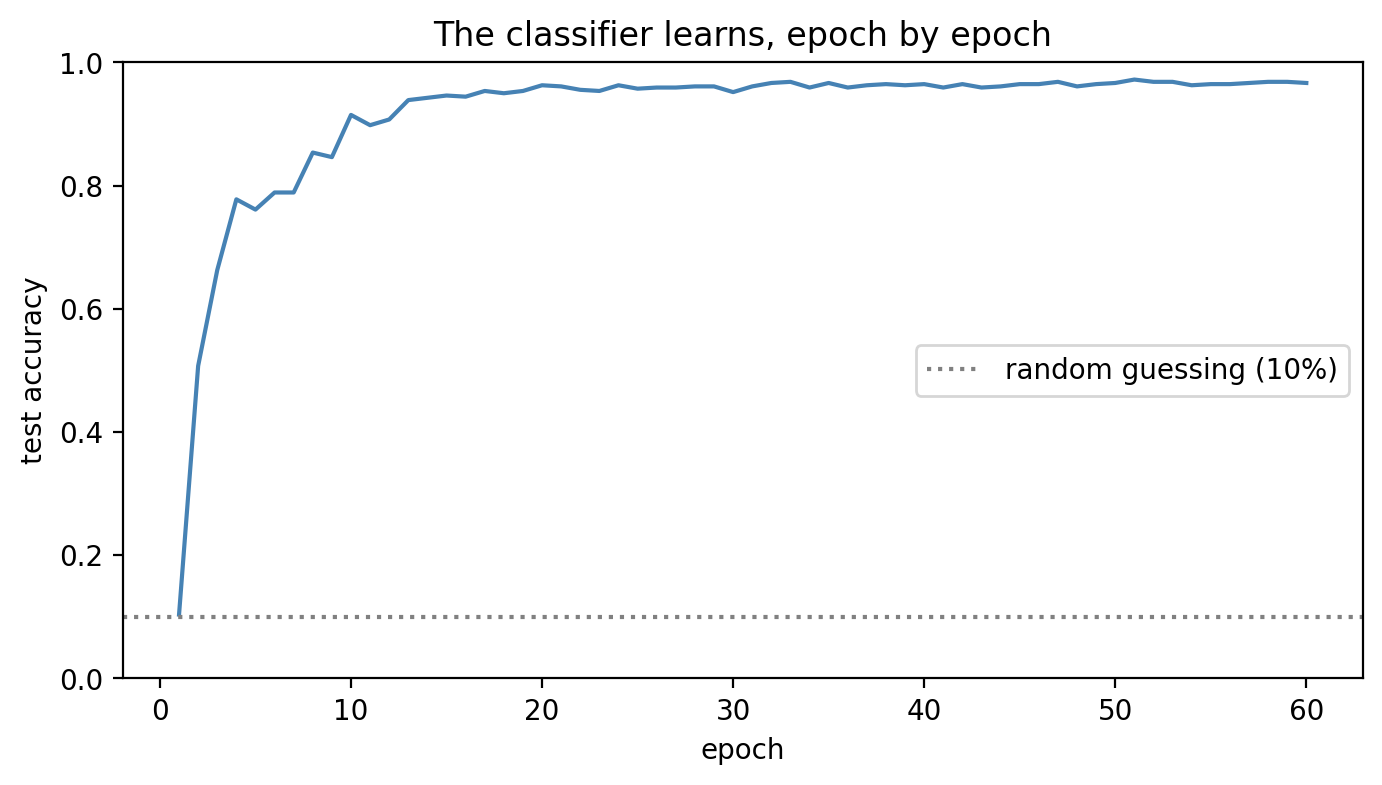

final test accuracy: 0.967  (522/540 correct)


In [30]:
W, b = init_layers([64, 32, 10], seed=1)                       # 64 inputs -> 32 hidden -> 10 classes
W, b, history = sgd(W, b, Xtr_, Ytr, lr=1.0, epochs=60, batch=16, seed=2, Xte=Xte_, yte=yte)

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
ax.plot(range(1, len(history) + 1), history, color='steelblue')
ax.axhline(0.1, color='gray', ls=':', label='random guessing (10%)')
ax.set_xlabel('epoch'); ax.set_ylabel('test accuracy')
ax.set_title('The classifier learns, epoch by epoch'); ax.set_ylim(0, 1); ax.legend()
plt.show()
print(f"final test accuracy: {history[-1]:.3f}  ({int(round(history[-1]*len(yte)))}/{len(yte)} correct)")

**Reading the curve:** It starts near 10% — a 10-way random guess — and climbs steeply as the mini-batch updates accumulate, settling around **97%**. Let's look at the predictions themselves, including the handful it gets wrong.

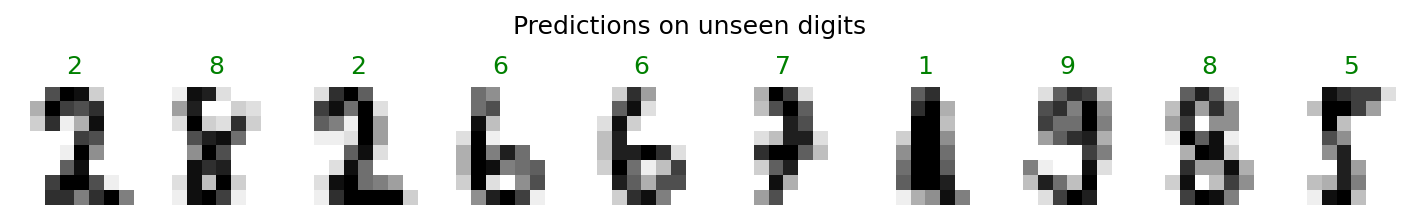

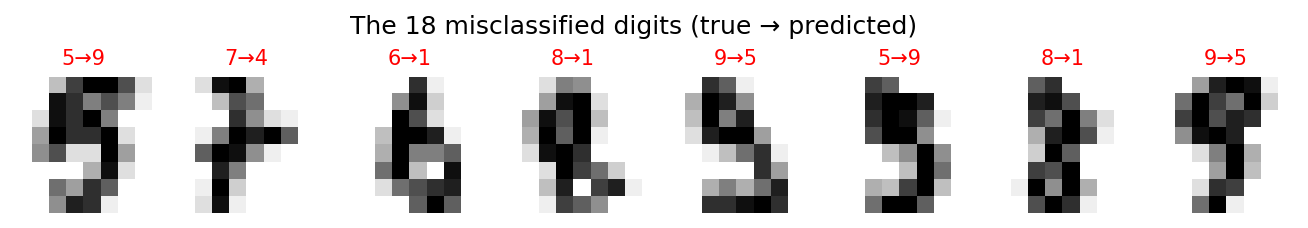

In [31]:
pred = predict(W, b, Xte_)

# a strip of test digits: title green if correct, red if wrong
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8), dpi=150)
for ax, img, pr, tr in zip(axes, Xte.reshape(-1, 8, 8), pred, yte):
    ax.imshow(img, cmap='gray_r'); ax.axis('off')
    ax.set_title(str(pr), color=('green' if pr == tr else 'red'))
plt.suptitle('Predictions on unseen digits'); plt.show()

# zoom in on the mistakes
wrong = np.where(pred != yte)[0]
fig, axes = plt.subplots(1, min(8, len(wrong)), figsize=(11, 1.8), dpi=150)
for ax, i in zip(np.atleast_1d(axes), wrong[:8]):
    ax.imshow(Xte[i].reshape(8, 8), cmap='gray_r'); ax.axis('off')
    ax.set_title(f'{yte[i]}→{pred[i]}', color='red', fontsize=10)
plt.suptitle(f'The {len(wrong)} misclassified digits (true → predicted)'); plt.show()

**Takeaway:** The identical neuron → forward → backprop → gradient-descent loop — now with a 10-way output, one-hot targets, and mini-batch SGD — reads unseen handwritten digits at ~97% accuracy. The few mistakes are mostly genuinely ambiguous scribbles. **Regression and classification are the same network**, differing only in the output layer, the target encoding, and how the prediction is read. For the full MNIST version (28×28 images, per-sample backprop written out step by step), see `neural-network-demo.ipynb` in this folder.

> In practice, you rarely write backpropagation by hand. Open-source libraries like **PyTorch** and **TensorFlow** make it easy to build and train neural networks without implementing the low-level details yourself — they provide the layers, **automatic differentiation** (so gradients are computed for you), and ready-made **optimizers**, collapsing the whole training loop into a handful of lines. We do it the hard way here precisely so those libraries feel like conveniences rather than magic: once you've written the neuron, the forward pass, and the gradients yourself, a line like `loss.backward()` is no longer a mystery.

## Summary

- A **neuron** is an adjustable soft step, $\sigma(wx+b)$: the **weight** sets its steepness, the **bias** sets its position.
- **Connecting neurons** into a hidden layer and summing them builds **plateaus, steps, and bumps** — shapes a straight line or a low-degree polynomial cannot make.
- **Backpropagation** computes the loss gradient for every weight via the chain rule; **gradient descent** then walks the weights downhill. Both are ~15 lines of NumPy.
- The trained network **learned a genuinely non-polynomial relationship** from data alone, reaching the noise floor and beating even a degree-10 polynomial.
- **Too much capacity overfits**: it memorises noise, achieving low training error but poor error on new data (the bias–variance trade-off).
- The **same network** does **classification**: swap to one output per class, one-hot targets, `argmax` predictions, and mini-batch SGD — and it reads handwritten digits at ~97%.
- A **validation set** lets us **tune the network size** honestly — pick the model that generalises, then report on a held-out **test set**.

The mechanics here scale directly to deep networks: more layers, more neurons, and specialised activations, but the same forward-pass / backprop / gradient-descent / validate loop.

## Exercises

1. **Learning rate.** In Section 3, retrain with `lr = 0.02` and `lr = 1.0`. What happens to the loss curve in each case? Which is too slow, and which is unstable?
2. **Capacity by hand.** Rerun Section 4 with `H = 2`, `H = 4`, and `H = 30`. How many hidden neurons does it take before the plateaus and the spike appear?
3. **Activation function.** Replace the sigmoid with the **ReLU**, $\ \mathrm{ReLU}(z) = \max(0, z)$, and its derivative (1 if $z>0$ else 0), by completing the stubs below. Retrain the Section 4 network. Does it still fit the curve?


lr = 0.02  loss 0.503 -> 0.101
lr = 0.3   loss 0.503 -> 0.042
lr = 1.0   loss 0.503 -> 0.045


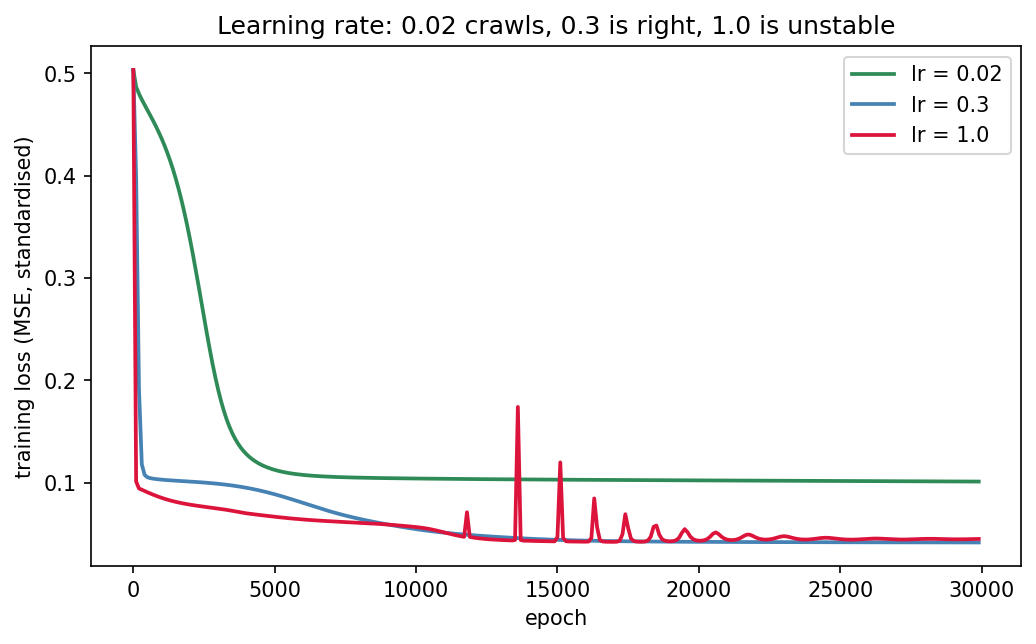

In [38]:
# Exercise 1 -- learning rate. Same Section-3 setup (H=12, full data), three rates.
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)

# Please add your learning rates to below codes. 

for lr, color in [(0.02, "seagreen"), (0.3, "steelblue"), (1.0, "crimson")]:
    with np.errstate(over="ignore", invalid="ignore"):   # lr=3.0 may overflow -- that's the point
        _, L = train(init_net(H=12, seed=10), X, Y, lr=lr, epochs=30000, record=True)
    ax.plot(np.arange(len(L)) * 100, L, color=color, lw=1.8, label=f"lr = {lr}")
    tag = "  (diverged)" if (not np.isfinite(L[-1])) or (L[-1] > L[0]) else ""
    print(f"lr = {lr:<5} loss {L[0]:.3f} -> {L[-1]:.3f}{tag}")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (MSE, standardised)")
# ax.set_yscale("log")
ax.set_title("Learning rate: 0.02 crawls, 0.3 is right, 1.0 is unstable")
ax.legend(); plt.show()

### Solution 2 — Capacity by hand

Fit the full dataset at `H = 2, 4, 30` and watch how many bends the network can afford. The **noise floor** here is MSE ≈ `1.2² = 1.44` — the best any model can do, since that is the variance we added.

**Answer:** With `H = 2` the network is short on S-curves and **underfits** (train MSE ≈ 2.5, well above the floor) — it catches the broad plateaus but flattens the spike. By `H = 4` it already reaches the noise floor (MSE ≈ 1.44): both **plateaus** *and* the **spike** are captured. Beyond that (`H = 8`, `30`) the error barely moves — extra neurons are capacity the problem doesn't need. So it takes only about **four** hidden neurons for all three features to appear.

H =  2   train MSE 2.50   (noise floor ~1.44)
H =  4   train MSE 1.44   (noise floor ~1.44)
H = 30   train MSE 1.42   (noise floor ~1.44)


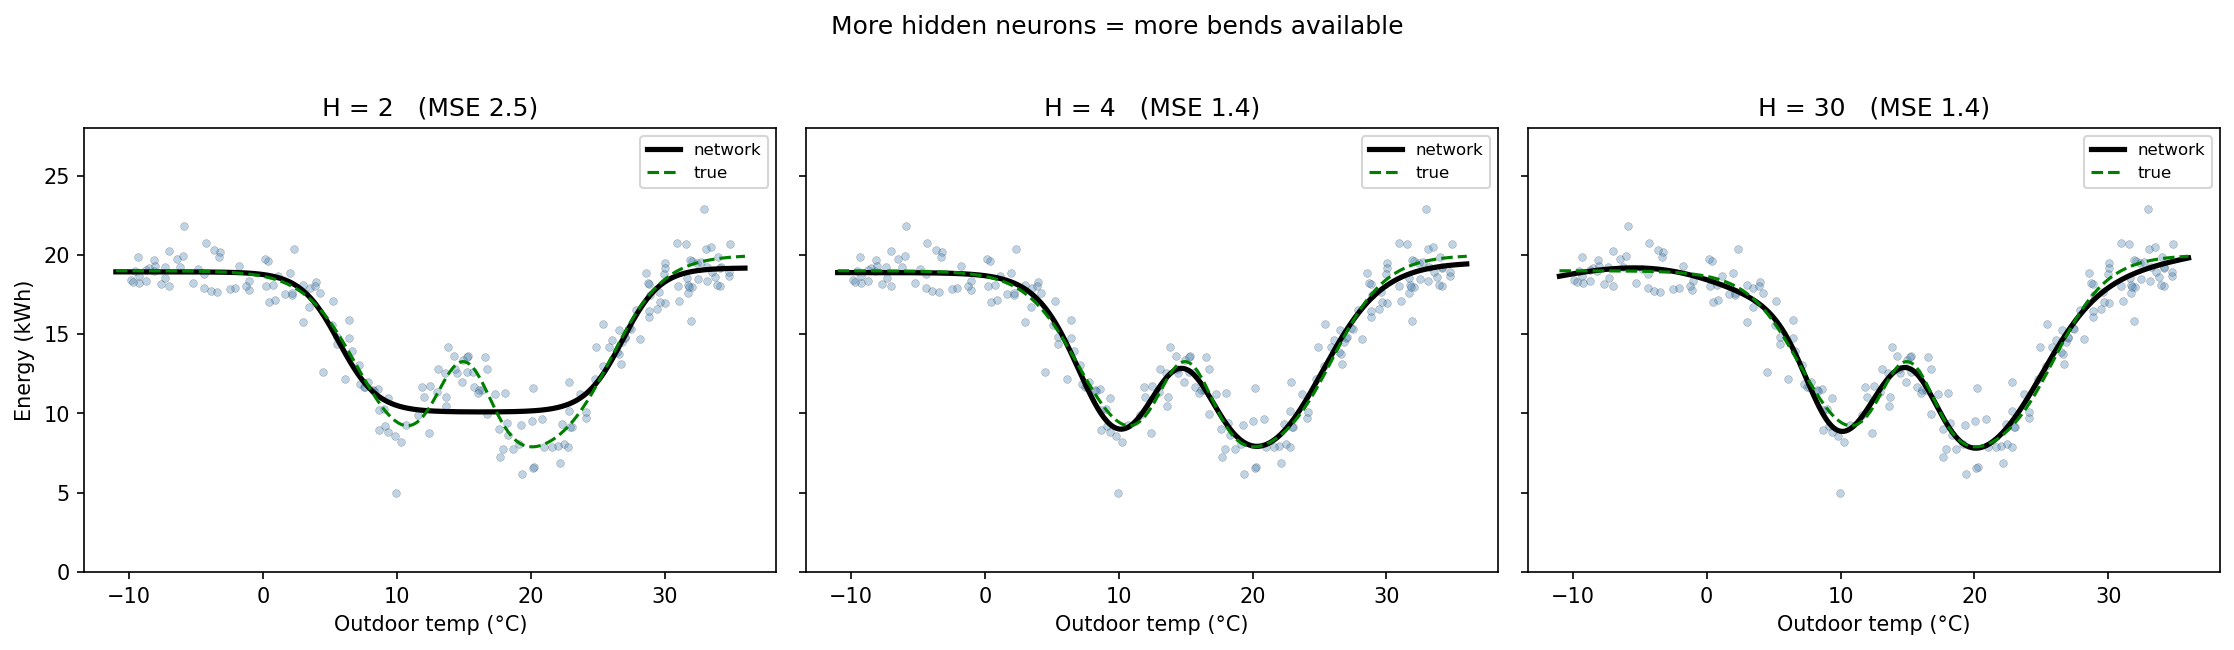

In [39]:
# Exercise 2 -- capacity. Fit the full dataset with increasing hidden size.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=150, sharey=True)
for ax, H in zip(axes, [2, 4, 30]):
    net_, _ = train(init_net(H=H, seed=10), X, Y, lr=0.3, epochs=30000)
    pred = sy.unz(forward(net_, sx.z(grid).reshape(1, -1))[0].ravel())
    mse = np.mean((sy.unz(forward(net_, X)[0].ravel()) - energy) ** 2)
    print(f"H = {H:>2}   train MSE {mse:.2f}   (noise floor ~1.44)")
    ax.scatter(Ti, energy, s=14, alpha=0.35, color="steelblue", edgecolor="black", linewidth=0.2)
    ax.plot(grid, pred, color="black", lw=2.5, label="network")
    ax.plot(grid, true_f(grid), "g--", lw=1.5, label="true")
    ax.set_title(f"H = {H}   (MSE {mse:.1f})")
    ax.set_xlabel("Outdoor temp (°C)"); ax.set_ylim(0, 28); ax.legend(fontsize=8)
axes[0].set_ylabel("Energy (kWh)")
plt.suptitle("More hidden neurons = more bends available", y=1.02)
plt.tight_layout(); plt.show()

### Solution 3 — ReLU activation

`relu(z) = max(0, z)`; its derivative is 1 where `z > 0` and 0 elsewhere. Because ReLU is unbounded (unlike the sigmoid's 0–1 range) the gradients are larger, so we use a **smaller learning rate** to stay stable. The hidden layer uses ReLU; the output neuron stays linear.

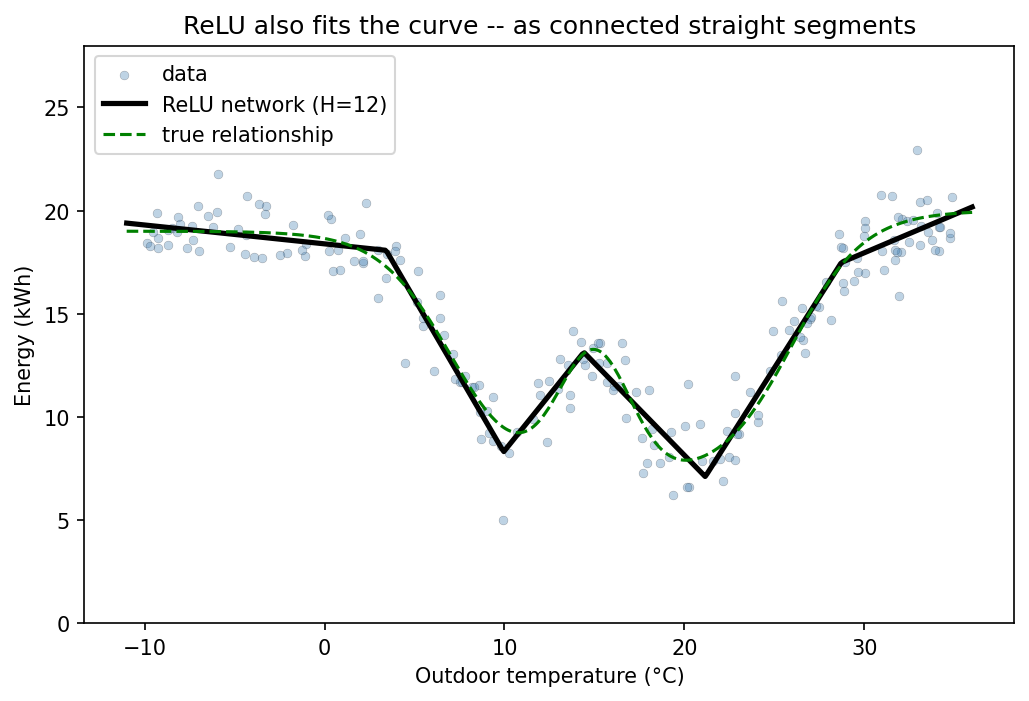

ReLU train MSE: 1.46


In [44]:
# Exercise 3 -- ReLU activation. Define relu / relu_prime, then retrain Section 4's net.
def relu(z):
    return np.maximum(0.0, z)

def relu_prime(z):
    return (z > 0).astype(float)

# forward / train that use ReLU in the hidden layer -- output stays linear
def forward_relu(net, X):
    Z1 = net["W1"] @ X + net["b1"]; A1 = relu(Z1)
    Z2 = net["W2"] @ A1 + net["b2"]
    return Z2, (Z1, A1)

def train_relu(net, X, Y, lr, epochs):
    N = X.shape[1]
    for _ in range(epochs):
        Yhat, (Z1, A1) = forward_relu(net, X)
        dZ2 = (Yhat - Y) / N
        dW2 = dZ2 @ A1.T; db2 = dZ2.sum(axis=1, keepdims=True)
        dZ1 = (net["W2"].T @ dZ2) * relu_prime(Z1)      # sigmoid_prime -> relu_prime
        dW1 = dZ1 @ X.T; db1 = dZ1.sum(axis=1, keepdims=True)
        net["W1"] -= lr * dW1; net["b1"] -= lr * db1
        net["W2"] -= lr * dW2; net["b2"] -= lr * db2
    return net

net_relu = train_relu(init_net(H=12, seed=10), X, Y, lr=0.05, epochs=40000)  # smaller lr for ReLU
pred = sy.unz(forward_relu(net_relu, sx.z(grid).reshape(1, -1))[0].ravel())

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.scatter(Ti, energy, s=18, alpha=0.35, color="steelblue", edgecolor="black", linewidth=0.2, label="data")
ax.plot(grid, pred, color="black", lw=2.5, label="ReLU network (H=12)")
ax.plot(grid, true_f(grid), "g--", lw=1.5, label="true relationship")
ax.set_ylim(0, 28); ax.set_xlabel("Outdoor temperature (°C)"); ax.set_ylabel("Energy (kWh)")
ax.set_title("ReLU also fits the curve -- as connected straight segments")
ax.legend(); plt.show()
print("ReLU train MSE:", round(float(np.mean((sy.unz(forward_relu(net_relu, X)[0].ravel()) - energy) ** 2)), 2))

## References
- Nielsen, *Neural Networks and Deep Learning* — http://neuralnetworksanddeeplearning.com/
- 3Blue1Brown, *Neural Networks* (visual intuition) — https://www.3blue1brown.com/topics/neural-networks
- The companion `neural-network-demo.ipynb` in this folder (same MLP idea, applied to MNIST digit classification).